# V12: Multi-GNN — Optuna HPO · Balanced Threshold · 5-Fold CV · Feature Importance

**Fixes over V7 + ROS Pipeline Added:**
- **Reduced Grade-1 recall**: class-weight penalty softened to `sqrt(ratio)` ≈ 1.18; per-fold G-mean threshold optimisation replaces fixed 0.5
- **AUC fix**: explicit named-column construction (no brittle positional rename); `try/except` guard for single-class folds
- **5-Fold Stratified CV**: Optuna finds best params once per model×pipeline, then `StratifiedKFold(5)` evaluates generalisation — reports mean ± std across folds
- Final model trained on full train+val, threshold = mean(fold thresholds), evaluated on held-out TCGA test + external CGGA
- **Pipeline D — ROS**: `RandomOverSampler` duplicates minority-class rows; applied strictly to the train partition to prevent any leakage into val/test

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC, RandomOverSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import os

def set_seed(seed=42):
    """Full determinism:
    - Python / NumPy / PyTorch RNGs
    - cuDNN deterministic algorithms (no non-deterministic scatter ops)
    - PYTHONHASHSEED for dict/set ordering
    NOTE: cudnn.deterministic=True adds ~10-20% training overhead.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # no non-det cuDNN kernels
    torch.backends.cudnn.benchmark     = False  # disable auto-tuner (picks diff algo each run)

set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 5. Build Shared Evaluation Graphs

In [5]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 5. Scale-Free Network Analysis

Tests whether the **gene-patient bipartite graph** (and derived patient–patient co-mutation graph) follow a **power-law degree distribution** — a hallmark of scale-free networks.

A network is considered scale-free when:
- **Exponent γ ∈ [2, 3]** for the fitted power-law P(k) ~ k^(−γ)
- **R² ≥ 0.80** on the log-log degree histogram (goodness of fit)
- **KS p-value > 0.05** (degree distribution consistent with power-law)

Both **gene degrees** (how many patients carry each mutation) and **patient degrees** (mutation burden) are tested.


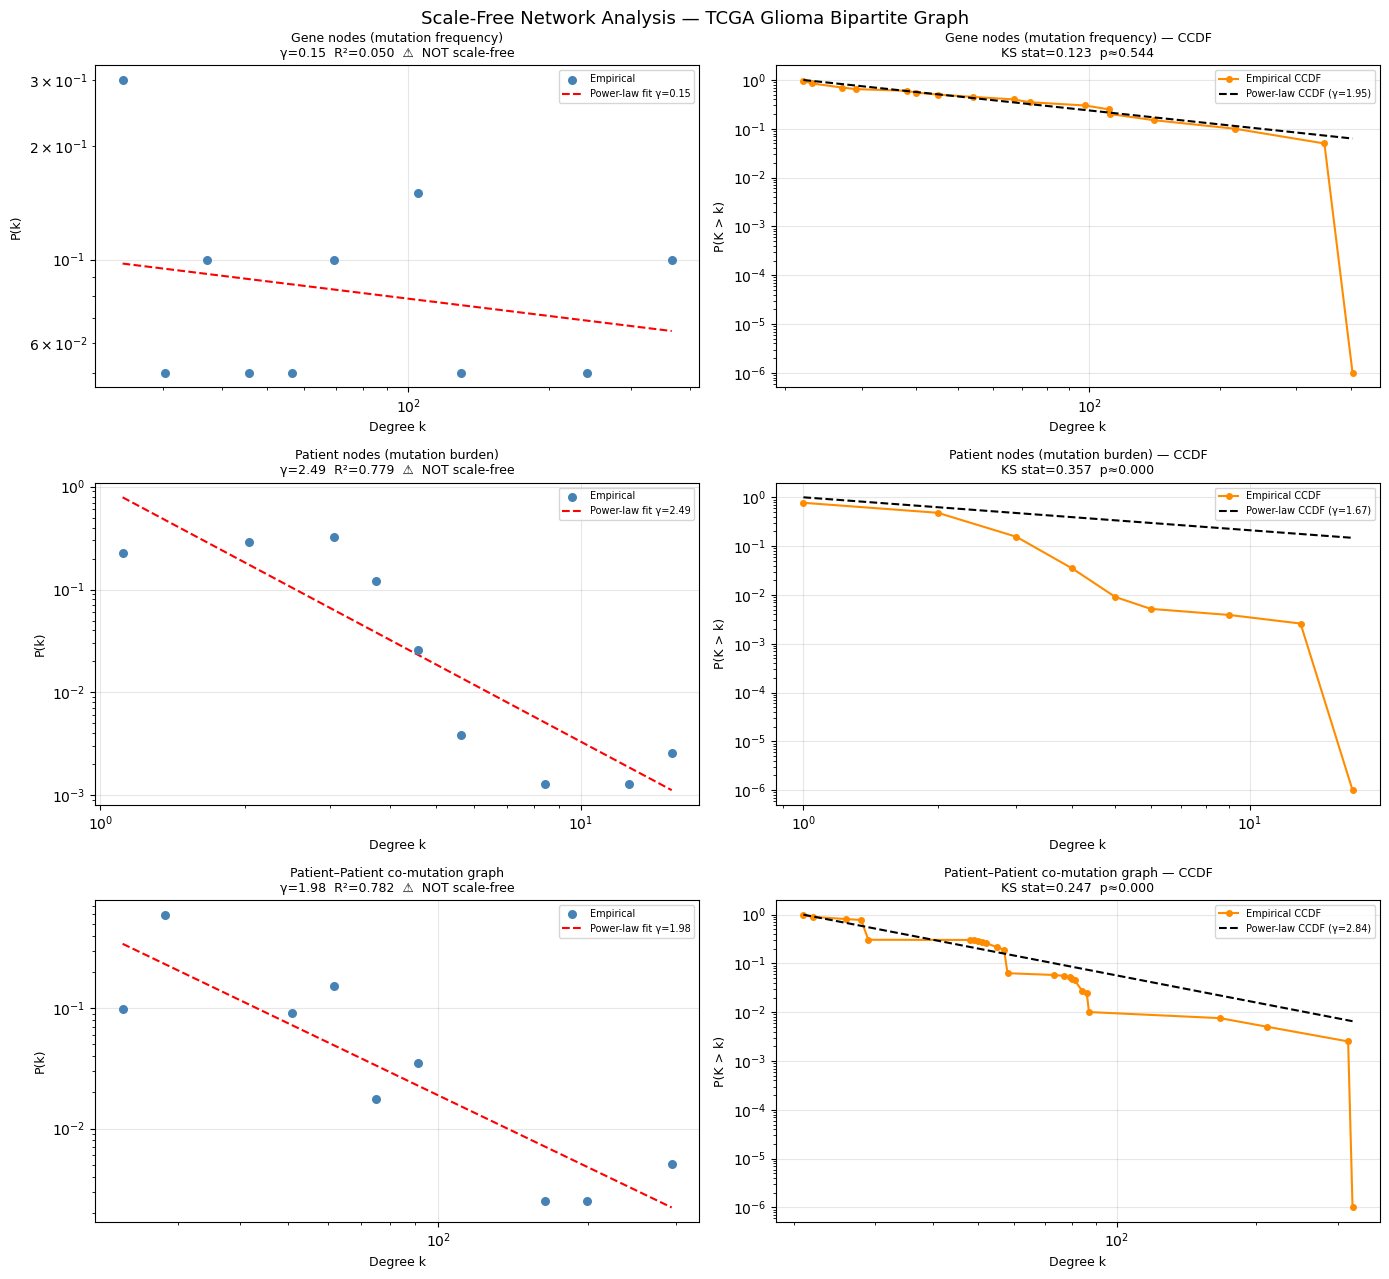


SCALE-FREE ANALYSIS SUMMARY
                        Node type   N  γ (OLS)  γ (MLE)     R²  KS stat   KS p            Verdict
  Gene nodes (mutation frequency)  20    0.153    1.949 0.0495   0.1233 0.5443 ⚠️  NOT scale-free
  Patient nodes (mutation burden) 772    2.490    1.675 0.7789   0.3575 0.0000 ⚠️  NOT scale-free
Patient–Patient co-mutation graph 396    1.984    2.840 0.7823   0.2467 0.0000 ⚠️  NOT scale-free

Interpretation:
  γ ∈ [2.0, 3.5] + R² ≥ 0.80 + KS p > 0.05  →  scale-free (power-law degree dist.)
  Scale-free topology = hubs (high-degree genes) drive message-passing in GNNs
  If NOT scale-free, consider degree-normalised aggregation (e.g. GCNConv norm)


In [6]:
# ── Scale-Free Network Analysis ──────────────────────────────────
# Uses the full TCGA dataset (pre-split) to analyse graph topology.
# No labels are used → no leakage risk.
from scipy import stats as sp_stats
from scipy.optimize import curve_fit

def _power_law(x, gamma, c):
    return c * (x ** (-gamma))

def analyse_scale_free(degree_seq, label, ax_hist, ax_ccdf):
    """
    Fit power-law to a degree sequence.
    Returns dict with gamma, r2, ks_p, verdict.
    Uses log-log regression on binned probability density +
    KS test of empirical CCDF vs fitted power-law CCDF.
    """
    deg = np.array(degree_seq, dtype=float)
    deg = deg[deg > 0]

    # ── Log-log OLS on histogram ──────────────────────────────
    counts, bin_edges = np.histogram(deg, bins=np.logspace(
        np.log10(deg.min()), np.log10(deg.max()), 15))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mask = counts > 0
    log_k = np.log10(bin_centers[mask])
    log_p = np.log10(counts[mask] / counts[mask].sum())
    slope, intercept, r, _, _ = sp_stats.linregress(log_k, log_p)
    gamma = -slope          # P(k) ~ k^(-gamma) → slope = -gamma
    r2    = r ** 2

    # ── KS test: empirical vs theoretical power-law CDF ──────
    k_min  = deg.min()
    # MLE gamma for discrete power-law: gamma_mle ≈ 1 + n / sum(ln(k/k_min-0.5))
    n      = len(deg)
    gamma_mle = 1 + n / np.sum(np.log(deg / (k_min - 0.5)))
    # Theoretical CDF P(K ≤ k) from continuous approximation
    def theo_cdf(k):
        return 1 - (k / k_min) ** (1 - gamma_mle)
    sorted_deg = np.sort(deg)
    empirical_cdf = np.arange(1, n + 1) / n
    theoretical_cdf = theo_cdf(sorted_deg).clip(0, 1)
    ks_stat = np.max(np.abs(empirical_cdf - theoretical_cdf))
    ks_p = np.exp(-2 * n * ks_stat ** 2)   # approximate p-value

    # ── Verdict ───────────────────────────────────────────────
    is_sf = (2.0 <= gamma <= 3.5) and (r2 >= 0.80) and (ks_p > 0.05)
    verdict = "✅ SCALE-FREE" if is_sf else "⚠️  NOT scale-free"

    # ── Plot 1: Log-log degree histogram ─────────────────────
    ax_hist.scatter(bin_centers[mask], counts[mask] / counts[mask].sum(),
                    s=30, color='steelblue', zorder=3, label='Empirical')
    k_fit = np.linspace(bin_centers[mask].min(), bin_centers[mask].max(), 200)
    ax_hist.plot(k_fit, 10 ** intercept * k_fit ** slope, 'r--', lw=1.5,
                 label=f'Power-law fit γ={gamma:.2f}')
    ax_hist.set_xscale('log'); ax_hist.set_yscale('log')
    ax_hist.set_xlabel('Degree k', fontsize=9)
    ax_hist.set_ylabel('P(k)', fontsize=9)
    ax_hist.set_title(f'{label}\nγ={gamma:.2f}  R²={r2:.3f}  {verdict}', fontsize=9)
    ax_hist.legend(fontsize=7); ax_hist.grid(alpha=0.3)

    # ── Plot 2: CCDF on log-log ───────────────────────────────
    unique_k, counts_k = np.unique(sorted_deg, return_counts=True)
    ccdf = 1 - np.cumsum(counts_k) / n
    ax_ccdf.loglog(unique_k, np.maximum(ccdf, 1e-6), 'o-', ms=4,
                   color='darkorange', label='Empirical CCDF')
    ccdf_fit = (unique_k / k_min) ** (1 - gamma_mle)
    ax_ccdf.loglog(unique_k, np.maximum(ccdf_fit.clip(0, 1), 1e-6), 'k--',
                   lw=1.5, label=f'Power-law CCDF (γ={gamma_mle:.2f})')
    ax_ccdf.set_xlabel('Degree k', fontsize=9)
    ax_ccdf.set_ylabel('P(K > k)', fontsize=9)
    ax_ccdf.set_title(f'{label} — CCDF\nKS stat={ks_stat:.3f}  p≈{ks_p:.3f}', fontsize=9)
    ax_ccdf.legend(fontsize=7); ax_ccdf.grid(alpha=0.3)

    return {'label': label, 'gamma': round(gamma, 3), 'gamma_mle': round(gamma_mle, 3),
            'r2': round(r2, 4), 'ks_stat': round(ks_stat, 4), 'ks_p': round(ks_p, 4),
            'is_scale_free': is_sf, 'verdict': verdict, 'n_nodes': n}


# ── Compute degree sequences from full TCGA graph ────────────────
# Uses tcga_df (all 839 patients) — no labels consumed → zero leakage
full_graph = construct_bipartite_heterograph(tcga_df)   # CPU graph
ei = full_graph[('Gene', 'mutates', 'Patient')].edge_index.numpy()

gene_degrees    = np.bincount(ei[0], minlength=NUM_GENES)   # degree of each gene node
patient_degrees = np.bincount(ei[1], minlength=len(tcga_df))  # mutation burden per patient

# ── Patient-patient co-mutation degree (for RGCN / SGNN) ─────────
pp_ei, _ = get_pp_edges(full_graph)
pp_ei_np = pp_ei.numpy()
pp_degrees = np.bincount(pp_ei_np[0], minlength=len(tcga_df))

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
plt.suptitle('Scale-Free Network Analysis — TCGA Glioma Bipartite Graph', fontsize=13)

results_sf = []
for row, (deg, lbl) in enumerate([
        (gene_degrees,    'Gene nodes (mutation frequency)'),
        (patient_degrees, 'Patient nodes (mutation burden)'),
        (pp_degrees,      'Patient–Patient co-mutation graph')]):
    r = analyse_scale_free(deg, lbl, axes[row, 0], axes[row, 1])
    results_sf.append(r)

plt.tight_layout()
plt.savefig('V12_scale_free.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────
sf_summary = pd.DataFrame(results_sf)[['label', 'n_nodes', 'gamma', 'gamma_mle',
                                         'r2', 'ks_stat', 'ks_p', 'verdict']]
sf_summary.columns = ['Node type', 'N', 'γ (OLS)', 'γ (MLE)', 'R²', 'KS stat', 'KS p', 'Verdict']
print("\n" + "="*75)
print("SCALE-FREE ANALYSIS SUMMARY")
print("="*75)
print(sf_summary.to_string(index=False))
print()
print("Interpretation:")
print("  γ ∈ [2.0, 3.5] + R² ≥ 0.80 + KS p > 0.05  →  scale-free (power-law degree dist.)")
print("  Scale-free topology = hubs (high-degree genes) drive message-passing in GNNs")
print("  If NOT scale-free, consider degree-normalised aggregation (e.g. GCNConv norm)")


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [7]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        return self.clf(g[:, :1] * hpg + g[:, 1:] * hpc)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei = pp_ei.to(xp.device); pp_et = pp_et.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph); pp_ei = pp_ei.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))




# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models: {[n for n,_,_ in MODEL_REGISTRY]}")

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [9]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN', 'ROS']

## 9. Unified Training Function

In [10]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42):
    """Train model; return (best_val_auc, best_state, history)."""
    set_seed(seed)   # reset RNG before every model init+train for reproducibility
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        logits = model(train_graph)
        loss   = criterion(logits, train_graph['Patient'].y)
        # Pick up optional aux_loss from models that expose it.
        # Existing models have no aux_loss so this never fires for them.
        aux = getattr(model, 'aux_loss', None)
        if aux is not None and torch.is_tensor(aux) and aux.requires_grad:
            loss = loss + aux
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [11]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        set_seed(42)   # same RNG state for every trial → fair comparison
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [12]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn._model_kwargs = {**getattr(syn, "_model_kwargs", {})}  # ensure fresh
    torch.manual_seed(42); np.random.seed(42)  # seed before CTGAN fit
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)



def apply_ros(fold_train_df):
    """Random Over-Sampling — duplicates minority rows in-place.

    NO-LEAKAGE GUARANTEE:
    - fit_resample() only reads the label vector to identify the minority class.
    - No statistics are derived from feature values; existing rows are
      duplicated with replacement, so no information from val/test can leak.
    - Called exclusively on fold_tr (the training partition) inside
      run_5fold_cv, and on train_val_df for the final model — test_df and
      cgga_df are never touched.
    """
    feat_cols = gene_columns + ['Gender', 'Race', 'Age_at_diagnosis']
    ros = RandomOverSampler(random_state=42)
    Xr, yr = ros.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols)
    df2['Grade'] = yr
    for c in gene_columns:
        df2[c] = df2[c].astype(int)  # preserve binary integer type
    return df2


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name):
    """Run StratifiedKFold(5) with fixed best_params.
    Returns DataFrame of per-fold metrics."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        set_seed(42)   # reset before each fold so augmentation + training are deterministic
        # Apply augmentation to training portion only
        if pipeline_name == 'SMOTE':
            fold_tr = apply_smote(fold_tr)
        elif pipeline_name == 'CTGAN':
            fold_tr = apply_ctgan(fold_tr)
        elif pipeline_name == 'ROS':
            fold_tr = apply_ros(fold_tr)   # duplicates minority rows — no leakage

        clear_pp_cache()    # prevent stale cache entries across folds
        tr_g = to_dev(construct_bipartite_heterograph(fold_tr))
        vl_g = to_dev(construct_bipartite_heterograph(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        # Build model for this fold
        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        # ── FIX: calibrated threshold per fold ────────────────────
        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} Acc={m['accuracy']:.3f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)

## 12. Pipeline Runner (shared by all 3 pipelines)

In [13]:
def run_pipeline(pipeline_name, train_graph_hpo, augment_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on train_df/val_df (or augmented version)
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (or augmented), calibrated threshold
      4. Evaluate on TCGA test + CGGA
    """
    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  ── {mname} ──")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw, pipeline_name, mname)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        full_tr_graph = to_dev(construct_bipartite_heterograph(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        # Threshold = mean of CV fold thresholds
        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} Acc={mt['accuracy']:.3f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} Acc={mc_['accuracy']:.3f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")

## 13. Pipeline A — No Balancing

In [14]:
train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None)


PIPELINE: No Balancing

  ── HeteroGATv2 ──


Best trial: 21. Best value: 0.932299: 100%|██████████| 30/30 [00:22<00:00,  1.36it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9323  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.003368951740328576, 'weight_decay': 0.00046278317037314027}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9262 Acc=0.896 R1=0.930 R0=0.872 F1=0.8833 th=0.43
    Fold 2/5 | AUC=0.9313 Acc=0.896 R1=0.893 R0=0.897 F1=0.8772 th=0.50
    Fold 3/5 | AUC=0.9002 Acc=0.866 R1=0.857 R0=0.872 F1=0.8421 th=0.54
    Fold 4/5 | AUC=0.9487 Acc=0.896 R1=0.911 R0=0.885 F1=0.8793 th=0.55
    Fold 5/5 | AUC=0.9285 Acc=0.873 R1=0.947 R0=0.818 F1=0.8640 th=0.50
    auc         : 0.9270 ± 0.0174
    accuracy    : 0.8852 ± 0.0147
    precision   : 0.8350 ± 0.0261
    recall      : 0.9076 ± 0.0348
    recall_0    : 0.8688 ± 0.0302
    f1          : 0.8692 ± 0.0168
    threshold   : 0.5040 ± 0.0472
  Final threshold (mean of CV folds) = 0.504
  TCGA-Test  AUC=0.9239 Acc=0.851 R1=0.843 R0=0.857 F1=0.8252
  CGGA       AUC=0.7590 Acc=0.671 R1=0.794 R0=0.603 F1=0.6328

  ── MOGAT ──


Best trial: 27. Best value: 0.944894: 100%|██████████| 30/30 [00:19<00:00,  1.53it/s]


  [MOGAT/No Balancing] Best AUC=0.9449  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.005138889731147795, 'weight_decay': 0.00017442343627131068}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9184 Acc=0.896 R1=0.930 R0=0.872 F1=0.8833 th=0.41
    Fold 2/5 | AUC=0.9169 Acc=0.873 R1=0.875 R0=0.872 F1=0.8522 th=0.51
    Fold 3/5 | AUC=0.9002 Acc=0.881 R1=0.911 R0=0.859 F1=0.8644 th=0.53
    Fold 4/5 | AUC=0.9460 Acc=0.910 R1=0.946 R0=0.885 F1=0.8983 th=0.52
    Fold 5/5 | AUC=0.9316 Acc=0.873 R1=0.947 R0=0.818 F1=0.8640 th=0.42
    auc         : 0.9226 ± 0.0172
    accuracy    : 0.8867 ± 0.0163
    precision   : 0.8287 ± 0.0228
    recall      : 0.9219 ± 0.0302
    recall_0    : 0.8611 ± 0.0256
    f1          : 0.8724 ± 0.0183
    threshold   : 0.4780 ± 0.0581
  Final threshold (mean of CV folds) = 0.478
  TCGA-Test  AUC=0.9156 Acc=0.845 R1=0.900 R0=0.806 F1=0.8289
  CGGA       AUC=0.7709 Acc=0.636 R1=0.784 R0=0.554 F1=0.6061

  ── HyperTMO ──


...

  [VEGN/No Balancing] Best AUC=0.9377  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.009658169798215889, 'weight_decay': 0.0002090515425762381}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9220 Acc=0.896 R1=0.930 R0=0.872 F1=0.8833 th=0.44
    Fold 2/5 | AUC=0.9174 Acc=0.888 R1=0.893 R0=0.885 F1=0.8696 th=0.49
    Fold 3/5 | AUC=0.9022 Acc=0.843 R1=0.875 R0=0.821 F1=0.8235 th=0.45
    Fold 4/5 | AUC=0.9499 Acc=0.888 R1=0.946 R0=0.846 F1=0.8760 th=0.49
    Fold 5/5 | AUC=0.9237 Acc=0.866 R1=0.947 R0=0.805 F1=0.8571 th=0.39
    auc         : 0.9230 ± 0.0172
    accuracy    : 0.8763 ± 0.0217
    precision   : 0.8129 ± 0.0322
    recall      : 0.9183 ± 0.0328
    recall_0    : 0.8457 ± 0.0334
    f1          : 0.8619 ± 0.0235
    threshold   : 0.4520 ± 0.0415
  Final threshold (mean of CV folds) = 0.452
  TCGA-Test  AUC=0.9103 Acc=0.827 R1=0.900 R0=0.776 F1=0.8129
  CGGA       AUC=0.7091 Acc=0.626 R1=0.794 R0=0.533 F1=0.6022

  ── FastHGTConv ──


Best trial: 22. Best value: 0.936347: 100%|██████████| 30/30 [00:48<00:00,  1.60s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9363  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.00469908082361728, 'weight_decay': 0.00014126983869081113}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9305 Acc=0.904 R1=0.912 R0=0.897 F1=0.8889 th=0.49
    Fold 2/5 | AUC=0.9357 Acc=0.888 R1=0.875 R0=0.897 F1=0.8673 th=0.48
    Fold 3/5 | AUC=0.9034 Acc=0.843 R1=0.929 R0=0.782 F1=0.8320 th=0.42
    Fold 4/5 | AUC=0.9435 Acc=0.896 R1=0.929 R0=0.872 F1=0.8814 th=0.52
    Fold 5/5 | AUC=0.9355 Acc=0.888 R1=0.965 R0=0.831 F1=0.8800 th=0.44
    auc         : 0.9297 ± 0.0154
    accuracy    : 0.8837 ± 0.0235
    precision   : 0.8255 ± 0.0460
    recall      : 0.9219 ± 0.0325
    recall_0    : 0.8560 ± 0.0494
    f1          : 0.8699 ± 0.0226
    threshold   : 0.4700 ± 0.0400
  Final threshold (mean of CV folds) = 0.470
  TCGA-Test  AUC=0.8448 Acc=0.792 R1=0.786 R0=0.796 F1=0.7586
  CGGA       AUC=0.7210 Acc=0.612 R1=0.784 R0=0.516 F1=0.5904

  ── SGNN ──


Best trial: 25. Best value: 0.918354: 100%|██████████| 30/30 [00:17<00:00,  1.76it/s]


  [SGNN/No Balancing] Best AUC=0.9184  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.0020219450031240776, 'weight_decay': 0.0003703183164354258}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8286 Acc=0.748 R1=0.825 R0=0.692 F1=0.7344 th=0.50
    Fold 2/5 | AUC=0.9121 Acc=0.851 R1=0.875 R0=0.833 F1=0.8305 th=0.40
    Fold 3/5 | AUC=0.8526 Acc=0.813 R1=0.804 R0=0.821 F1=0.7826 th=0.58
    Fold 4/5 | AUC=0.8974 Acc=0.843 R1=0.893 R0=0.808 F1=0.8264 th=0.51
    Fold 5/5 | AUC=0.9052 Acc=0.858 R1=0.895 R0=0.831 F1=0.8430 th=0.50
    auc         : 0.8792 ± 0.0366
    accuracy    : 0.8228 ± 0.0450
    precision   : 0.7562 ± 0.0546
    recall      : 0.8581 ± 0.0416
    recall_0    : 0.7970 ± 0.0594
    f1          : 0.8034 ± 0.0448
    threshold   : 0.4980 ± 0.0642
  Final threshold (mean of CV folds) = 0.498
  TCGA-Test  AUC=0.8636 Acc=0.792 R1=0.871 R0=0.735 F1=0.7771
  CGGA       AUC=0.6871 Acc=0.357 R1=1.000 R0=0.000 F1=0.5258

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [15]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  ── HeteroGATv2 ──


Best trial: 25. Best value: 0.931849: 100%|██████████| 30/30 [00:21<00:00,  1.39it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9318  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.006721075801867154, 'weight_decay': 0.00033812616524231344}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9285 Acc=0.896 R1=0.930 R0=0.872 F1=0.8833 th=0.43
    Fold 2/5 | AUC=0.9270 Acc=0.896 R1=0.893 R0=0.897 F1=0.8772 th=0.48
    Fold 3/5 | AUC=0.9043 Acc=0.851 R1=0.911 R0=0.808 F1=0.8361 th=0.44
    Fold 4/5 | AUC=0.9451 Acc=0.896 R1=0.911 R0=0.885 F1=0.8793 th=0.56
    Fold 5/5 | AUC=0.9260 Acc=0.866 R1=0.947 R0=0.805 F1=0.8571 th=0.47
    auc         : 0.9262 ± 0.0145
    accuracy    : 0.8808 ± 0.0212
    precision   : 0.8217 ± 0.0410
    recall      : 0.9183 ± 0.0209
    recall_0    : 0.8533 ± 0.0438
    f1          : 0.8666 ± 0.0198
    threshold   : 0.4760 ± 0.0513
  Final threshold (mean of CV folds) = 0.476
  TCGA-Test  AUC=0.9064 Acc=0.839 R1=0.929 R0=0.776 F1=0.8280
  CGGA       AUC=0.7676 Acc=0.629 R1=0.843 R0=0.511 F1=0.6187

  ── MOGAT ──


Best trial: 28. Best value: 0.936572: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


  [MOGAT/SMOTE] Best AUC=0.9366  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0018479609694215691, 'weight_decay': 0.00010915594925918693}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9211 Acc=0.904 R1=0.930 R0=0.885 F1=0.8908 th=0.53
    Fold 2/5 | AUC=0.9135 Acc=0.873 R1=0.893 R0=0.859 F1=0.8547 th=0.48
    Fold 3/5 | AUC=0.8984 Acc=0.866 R1=0.857 R0=0.872 F1=0.8421 th=0.56
    Fold 4/5 | AUC=0.9441 Acc=0.910 R1=0.911 R0=0.910 F1=0.8947 th=0.59
    Fold 5/5 | AUC=0.9378 Acc=0.873 R1=0.947 R0=0.818 F1=0.8640 th=0.45
    auc         : 0.9230 ± 0.0185
    accuracy    : 0.8852 ± 0.0203
    precision   : 0.8351 ± 0.0329
    recall      : 0.9076 ± 0.0348
    recall_0    : 0.8688 ± 0.0340
    f1          : 0.8693 ± 0.0228
    threshold   : 0.5220 ± 0.0572
  Final threshold (mean of CV folds) = 0.522
  TCGA-Test  AUC=0.9173 Acc=0.851 R1=0.871 R0=0.837 F1=0.8299
  CGGA       AUC=0.7287 Acc=0.647 R1=0.755 R0=0.587 F1=0.6039

  ── HyperTMO ──


...

  [VEGN/SMOTE] Best AUC=0.9366  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.005026151608875438, 'weight_decay': 0.0007947216892705835}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9229 Acc=0.896 R1=0.930 R0=0.872 F1=0.8833 th=0.51
    Fold 2/5 | AUC=0.9096 Acc=0.888 R1=0.857 R0=0.910 F1=0.8649 th=0.56
    Fold 3/5 | AUC=0.9011 Acc=0.828 R1=0.929 R0=0.756 F1=0.8189 th=0.44
    Fold 4/5 | AUC=0.9512 Acc=0.896 R1=0.911 R0=0.885 F1=0.8793 th=0.57
    Fold 5/5 | AUC=0.9246 Acc=0.858 R1=0.930 R0=0.805 F1=0.8480 th=0.50
    auc         : 0.9219 ± 0.0191
    accuracy    : 0.8733 ± 0.0295
    precision   : 0.8152 ± 0.0577
    recall      : 0.9112 ± 0.0313
    recall_0    : 0.8457 ± 0.0632
    f1          : 0.8589 ± 0.0263
    threshold   : 0.5160 ± 0.0522
  Final threshold (mean of CV folds) = 0.516
  TCGA-Test  AUC=0.9160 Acc=0.833 R1=0.900 R0=0.786 F1=0.8182
  CGGA       AUC=0.7047 Acc=0.629 R1=0.784 R0=0.543 F1=0.6015

  ── FastHGTConv ──


Best trial: 12. Best value: 0.933198: 100%|██████████| 30/30 [00:56<00:00,  1.89s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9332  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0037850972969548065, 'weight_decay': 0.0002795929705001659}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9318 Acc=0.896 R1=0.912 R0=0.885 F1=0.8814 th=0.51
    Fold 2/5 | AUC=0.9304 Acc=0.903 R1=0.893 R0=0.910 F1=0.8850 th=0.50
    Fold 3/5 | AUC=0.9119 Acc=0.866 R1=0.839 R0=0.885 F1=0.8393 th=0.59
    Fold 4/5 | AUC=0.9462 Acc=0.896 R1=0.946 R0=0.859 F1=0.8833 th=0.58
    Fold 5/5 | AUC=0.9314 Acc=0.881 R1=0.965 R0=0.818 F1=0.8730 th=0.45
    auc         : 0.9303 ± 0.0122
    accuracy    : 0.8882 ± 0.0150
    precision   : 0.8388 ± 0.0296
    recall      : 0.9112 ± 0.0491
    recall_0    : 0.8713 ± 0.0348
    f1          : 0.8724 ± 0.0191
    threshold   : 0.5260 ± 0.0586
  Final threshold (mean of CV folds) = 0.526
  TCGA-Test  AUC=0.9152 Acc=0.851 R1=0.914 R0=0.806 F1=0.8366
  CGGA       AUC=0.6995 Acc=0.647 R1=0.588 R0=0.679 F1=0.5430

  ── SGNN ──


Best trial: 3. Best value: 0.903284: 100%|██████████| 30/30 [00:16<00:00,  1.82it/s]


  [SGNN/SMOTE] Best AUC=0.9033  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.0023359635026261607, 'weight_decay': 7.591104805282687e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8273 Acc=0.756 R1=0.807 R0=0.718 F1=0.7360 th=0.49
    Fold 2/5 | AUC=0.9137 Acc=0.873 R1=0.839 R0=0.897 F1=0.8468 th=0.53
    Fold 3/5 | AUC=0.8555 Acc=0.821 R1=0.786 R0=0.846 F1=0.7857 th=0.57
    Fold 4/5 | AUC=0.8965 Acc=0.851 R1=0.911 R0=0.808 F1=0.8361 th=0.55
    Fold 5/5 | AUC=0.9027 Acc=0.851 R1=0.825 R0=0.870 F1=0.8246 th=0.59
    auc         : 0.8791 ± 0.0364
    accuracy    : 0.8302 ± 0.0457
    precision   : 0.7828 ± 0.0677
    recall      : 0.8335 ± 0.0476
    recall_0    : 0.8279 ± 0.0697
    f1          : 0.8058 ± 0.0454
    threshold   : 0.5460 ± 0.0385
  Final threshold (mean of CV folds) = 0.546
  TCGA-Test  AUC=0.8420 Acc=0.768 R1=0.886 R0=0.684 F1=0.7607
  CGGA       AUC=0.6095 Acc=0.531 R1=0.480 R0=0.560 F1=0.4224

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [ ]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan)


Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 337.08it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  ── HeteroGATv2 ──


Best trial: 16. Best value: 0.936797: 100%|██████████| 30/30 [00:19<00:00,  1.57it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9368  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.009913601801159863, 'weight_decay': 0.0005271506388056993}
  5-Fold CV with best params:


...

    Fold 3/5 | AUC=0.9036 Acc=0.828 R1=0.875 R0=0.795 F1=0.8099 th=0.53


Sampling conditions: 100%|██████████| 85/85 [00:00<00:00, 403.31it/s]


    Fold 4/5 | AUC=0.9547 Acc=0.903 R1=0.946 R0=0.872 F1=0.8908 th=0.56


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 534.87it/s]


    Fold 5/5 | AUC=0.9084 Acc=0.851 R1=0.947 R0=0.779 F1=0.8438 th=0.53
    auc         : 0.9194 ± 0.0207
    accuracy    : 0.8644 ± 0.0286
    precision   : 0.7960 ± 0.0440
    recall      : 0.9147 ± 0.0369
    recall_0    : 0.8276 ± 0.0475
    f1          : 0.8504 ± 0.0292
    threshold   : 0.5300 ± 0.0308


## 16. Pipeline D — ROS (Random Over-Sampling)

In [ ]:
# ── ROS: duplicate minority rows on train_df for HPO graph ───────
# NO LEAKAGE: RandomOverSampler is fit+applied to train_df only.
# val_df, test_df, and cgga_df are never seen here.
feat_cols_ros = gene_columns + ['Gender', 'Race', 'Age_at_diagnosis']
ros_hpo = RandomOverSampler(random_state=42)
Xr_hpo, yr_hpo = ros_hpo.fit_resample(train_df[feat_cols_ros], train_df['Grade'])
train_ros_df = pd.DataFrame(Xr_hpo, columns=feat_cols_ros)
train_ros_df['Grade'] = yr_hpo
for c in gene_columns:
    train_ros_df[c] = train_ros_df[c].astype(int)
print("ROS HPO graph class dist:\n", train_ros_df['Grade'].value_counts())

train_ros_graph = to_dev(construct_bipartite_heterograph(train_ros_df))
run_pipeline('ROS', train_graph_hpo=train_ros_graph, augment_fn=apply_ros)

print("\n✓ All 28 model × pipeline combinations complete.")


## 16. 5-Fold CV Summary Table

In [ ]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [ ]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V12_results_final.csv', index=False)
print("\n✓ Exported: V12_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V12_cv_summary.csv', index=False)
    cv_all.to_csv('V12_cv_folds.csv', index=False)
    print("✓ Exported: V12_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V12_cv_folds.csv    (raw per-fold results)")

## 18. AUC Heatmaps

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN', 'ROS']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V12_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN', 'ROS']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V12_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

In [ ]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V12_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

In [ ]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato', 'ROS':'darkorchid'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V12_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

In [ ]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V12_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Feature Importance — Genes + Clinical Features

For every feature (20 gene mutations + 3 clinical: **Age_at_diagnosis, Gender, Race**),
the column is shuffled `n_repeats=10` times and the mean AUC drop is recorded.

- **Gene features** are permuted as binary mutation columns
- **Clinical features** are permuted as continuous/categorical columns in the same way
- The graph is rebuilt from scratch after each permutation so the message-passing
  structure reflects the shuffled values
- Larger AUC drop → feature is more important for classification

In [ ]:
# All features subject to permutation importance
CLINICAL_FEATURES = ['Age_at_diagnosis', 'Gender', 'Race']
ALL_FEATURES      = gene_columns + CLINICAL_FEATURES   # 20 genes + 3 clinical = 23 total


def perm_importance_all(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    """Permutation importance for ALL features (genes + clinical).
    Returns ({feature: mean_auc_drop}, base_auc).
    """
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {f: 0.0 for f in ALL_FEATURES}, 0.0

    rng = np.random.default_rng(seed)
    out = {}

    for feat in ALL_FEATURES:
        drops = []
        for _ in range(n_repeats):
            df2         = ref_df.copy()
            df2[feat]   = rng.permutation(df2[feat].values)  # shuffle this feature
            g2          = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[feat] = float(np.mean(drops))

    clear_pp_cache()
    return out, base_auc


print("Computing permutation importance for genes + clinical features...")
print(f"Features: {len(ALL_FEATURES)} total ({len(gene_columns)} genes + {len(CLINICAL_FEATURES)} clinical)")
print(f"Models: {len(MODEL_REGISTRY)} × Pipelines: {len(PIPELINES)} = {len(MODEL_REGISTRY)*len(PIPELINES)} combinations")
print(f"Repeats per feature: 10  →  Total graph builds: {len(ALL_FEATURES)*10*len(MODEL_REGISTRY)*len(PIPELINES):,}")

imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th        = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance_all(model, test_df, threshold=th)
        for feat, drop in imp.items():
            imp_records.append({
                'Model':        mname,
                'Pipeline':     pipe,
                'Feature':      feat,
                'Feature_Type': 'Clinical' if feat in CLINICAL_FEATURES else 'Gene',
                'AUC_Drop':     drop,
                'Base_AUC':     base,
            })
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
imp_df.to_csv('V12_feature_importance.csv', index=False)
print(f"\nDone. Saved V12_feature_importance.csv ({len(imp_df)} rows)")

## 24. Feature Importance Plots — Genes + Clinical

In [ ]:
# ── Aggregate: mean AUC drop per feature across all models & pipelines ──
mean_imp = (imp_df.groupby(['Feature','Feature_Type'])['AUC_Drop']
            .mean()
            .reset_index()
            .sort_values('AUC_Drop', ascending=False)
            .reset_index(drop=True))

# Colour: orange for clinical, steelblue for gene
bar_colors = ['#E87722' if t == 'Clinical' else '#4C8AC4'
              for t in mean_imp['Feature_Type']]

# ─────────────────────────────────────────────────────────────────
# PLOT A: Combined bar chart — all 23 features, colour-coded by type
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mean_imp['Feature'], mean_imp['AUC_Drop'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Permutation Feature Importance — Genes (blue) + Clinical (orange)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp['AUC_Drop']):
    ax.text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=6.5)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C8AC4', label='Gene mutation'),
                    Patch(color='#E87722', label='Clinical feature')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('V12_feat_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT B: Side-by-side — Gene panel | Clinical panel
# ─────────────────────────────────────────────────────────────────
gene_imp = mean_imp[mean_imp.Feature_Type == 'Gene'].copy()
clin_imp = mean_imp[mean_imp.Feature_Type == 'Clinical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 5),
                          gridspec_kw={'width_ratios': [len(gene_imp), len(clin_imp)]})

# Gene panel
gcols = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gene_imp)))
b1 = axes[0].bar(gene_imp['Feature'], gene_imp['AUC_Drop'], color=gcols, edgecolor='white')
axes[0].set_title('Gene Mutation Importance', fontsize=12)
axes[0].set_xlabel('Gene'); axes[0].set_ylabel('Mean AUC Drop')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(b1, gene_imp['AUC_Drop']):
    axes[0].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=7)

# Clinical panel
ccols = plt.cm.Oranges(np.linspace(0.45, 0.85, len(clin_imp)))
b2 = axes[1].bar(clin_imp['Feature'], clin_imp['AUC_Drop'], color=ccols, edgecolor='white',
                  width=0.5)
axes[1].set_title('Clinical Feature Importance', fontsize=12)
axes[1].set_xlabel('Clinical Feature'); axes[1].set_ylabel('Mean AUC Drop')
axes[1].tick_params(axis='x', rotation=0, labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(b2, clin_imp['AUC_Drop']):
    axes[1].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Importance by Category', fontsize=13)
plt.tight_layout()
plt.savefig('V12_feat_importance_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT C: Heatmap — all 23 features × 7 models (averaged over pipelines)
# ─────────────────────────────────────────────────────────────────
# Column order: clinical first, then genes sorted by mean importance
col_order = (list(clin_imp['Feature']) +
             list(gene_imp.sort_values('AUC_Drop', ascending=False)['Feature']))

heat = (imp_df.groupby(['Model','Feature'])['AUC_Drop']
        .mean()
        .unstack('Feature')
        .reindex(columns=col_order))

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.35,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})

# Vertical separator between clinical and gene columns
ax.axvline(x=len(CLINICAL_FEATURES), color='navy', lw=2.5, ls='--')

ax.set_title('Permutation Importance Heatmap — All Features × All Models\n'
             '(dashed line separates Clinical | Gene)', fontsize=12)

ax.set_xlabel('Feature'); ax.set_ylabel('Model')

# Colour x-tick labels by type
for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color('#E87722' if feat in CLINICAL_FEATURES else '#1a1a1a')
    tick.set_fontsize(8)

plt.tight_layout()
plt.savefig('V12_feat_importance_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT D: Per-pipeline importance — clinical vs gene
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline == pipe]
           .groupby(['Feature','Feature_Type'])['AUC_Drop'].mean()
           .reset_index()
           .sort_values('AUC_Drop', ascending=False))
    colors_p = ['#E87722' if t == 'Clinical' else '#4C8AC4'
                for t in sub['Feature_Type']]
    axes[pi].bar(sub['Feature'], sub['AUC_Drop'], color=colors_p, edgecolor='white')
    axes[pi].set_title(f'{pipe}', fontsize=10)
    axes[pi].set_xlabel('Feature'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45, labelsize=7)
    axes[pi].grid(axis='y', alpha=0.3)
    axes[pi].legend(handles=[Patch(color='#4C8AC4', label='Gene'),
                               Patch(color='#E87722', label='Clinical')],
                     fontsize=7)
plt.suptitle('Feature Importance Per Pipeline (Gene + Clinical)', fontsize=13)
plt.tight_layout()
plt.savefig('V12_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print("\nOVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)")
print("="*65)
for i, row in mean_imp.iterrows():
    tag = '[CLINICAL]' if row['Feature_Type'] == 'Clinical' else '[GENE]   '
    print(f"  {i+1:2d}. {tag}  {row['Feature']:20s}  {row['AUC_Drop']:.4f}")

print(f"\nClinical features summary:")
for _, row in clin_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

print(f"\nTop-5 gene features:")
for _, row in gene_imp.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

## 25. GAT & MOGAT Attention Weights

**HeteroGATv2**: gene→patient GATv2 attention.  
**MOGAT**: same gene→patient GATv2 genomic attention **plus** the fusion gate values showing how much each patient relies on the genomic vs clinical pathway.

In [ ]:
def plot_gene_attention(model, graph, ref_df, title):
    """Visualise gene->patient attention for any model that exposes get_attn_weights().
    For MOGAT the function also prints the fusion gate split (printed inside get_attn_weights).
    """
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    pat_ids  = eidx[1].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention weight per gene (averaged over all edges touching that gene)
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    # Top-10 genes and top-15 patients by total received attention
    n_pat = ref_df.shape[0]
    top_g  = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]

    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Bar chart: mean attention per gene
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene→Patient Attention\n({title})')
    axes[0].set_ylabel('Mean Attention Weight'); axes[0].grid(axis='y', alpha=0.3)

    # Heatmap: top genes × top patients
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes × Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient Index'); axes[1].set_ylabel('Gene')

    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V12_attn_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── MOGAT: also show per-patient fusion gate distribution ─────────
def plot_mogat_fusion_gate(model, graph, ref_df, title):
    """Show the distribution of genomic vs clinical pathway weights
    (the learned soft gate) across all patients."""
    model.eval()
    if not isinstance(model, MOGAT):
        return
    with torch.no_grad():
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(model.pg(graph['Patient'].x))
        hgg = F.relu(model.gg(graph['Gene'].x))
        hpg_out = F.leaky_relu(model.gat((hgg, hpg), e), 0.2)
        hpc     = model.mlp(F.relu(model.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(model.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        gw      = gate_w.cpu().numpy()   # [n_patients, 2]  col0=genomic, col1=clinical

    labels  = ref_df['Grade'].values
    grades  = ['Grade 0', 'Grade 1']
    colors  = ['#4C8AC4', '#E87722']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram of genomic gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[0].hist(gw[mask, 0], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[0].set_xlabel('Genomic pathway gate weight'); axes[0].set_ylabel('Density')
    axes[0].set_title('Genomic Gate Weight Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram of clinical gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[1].hist(gw[mask, 1], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[1].set_xlabel('Clinical pathway gate weight'); axes[1].set_ylabel('Density')
    axes[1].set_title('Clinical Gate Weight Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Scatter: genomic vs clinical gate per patient, coloured by grade
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[2].scatter(gw[mask, 0], gw[mask, 1], c=color, label=lbl,
                         alpha=0.5, s=20, edgecolors='none')
    axes[2].plot([0,1],[1,0],'k--', alpha=0.3, lw=1)   # gate sums to 1
    axes[2].set_xlabel('Genomic gate'); axes[2].set_ylabel('Clinical gate')
    axes[2].set_title('Pathway Gate per Patient'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'MOGAT Fusion Gate Analysis — {title}', fontsize=12)
    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V12_mogat_gate_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run for HeteroGATv2 and MOGAT across all pipelines ───────────
for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m is None: continue
        print(f"\nAttention: {mname} / {pipe}")
        plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")
        if mname == 'MOGAT':
            plot_mogat_fusion_gate(m, test_graph, test_df, f"{pipe}")


## 26. Classification Reports — Best Model Overall

In [ ]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

## 27. Save Results

In [ ]:
# import os
# os.makedirs('saved_models_v10', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v10/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V12_thresholds.csv', index=False)
if 'imp_df' in dir() and not imp_df.empty:
    imp_df.to_csv('V12_feature_importance.csv', index=False)
    print("✓ Exported: V12_feature_importance.csv")

print("✓ Saved model weights to saved_models_v10/")
print("\nFinal AUC Pivot:")
print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
                              values='AUC', aggfunc='mean').round(4).to_string())

## 28. Graph-Specific XAI — Heterogeneous Scale-Free Network Explanations

Standard permutation feature importance treats every patient independently and ignores  
graph topology entirely.  Here we implement **three complementary graph-native XAI methods**  
that respect the bipartite Gene–Patient structure and the scale-free degree distribution:

| Method | Scope | Key idea |
|--------|-------|----------|
| **Gradient × Input** | Node-level, differentiable | ∂P(ŷ)/∂h_gene × h_gene — measures how much each gene's embedding steers a patient's prediction |
| **Occlusion / Edge Knockout** | Edge-level, model-agnostic | Zero out gene node; ΔP(ŷ) is the edge's causal importance |
| **HeteroGNNExplainer** | Subgraph-level, optimisation | Learns soft edge-masks M_E ∈ [0,1] per Gene→Patient edge that maximise fidelity + sparsity |

Scale-free correction: raw importance scores are **degree-normalised** so hub genes  
(mutated in many patients) are not trivially ranked highest merely by frequency.

All three methods are run for every patient in TCGA-test and CGGA, then aggregated  
to a population-level gene ranking that can be compared against the permutation  
importance computed in §23.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# §28  Graph-Specific XAI — core utilities
# ═══════════════════════════════════════════════════════════════
import networkx as nx
from collections import defaultdict
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.colors import Normalize
from matplotlib import cm as mpl_cm

# ── helper: rebuild HeteroData with a swapped Gene.x ─────────
def _rebuild(ref, new_gene_x=None):
    """
    Return a NEW HeteroData that shares all structure with `ref`
    but uses `new_gene_x` for Gene features.  Gradient-safe.
    """
    from torch_geometric.data import HeteroData
    g = HeteroData()
    g['Patient'].x = ref['Patient'].x
    g['Patient'].y = ref['Patient'].y
    g['Gene'].x    = ref['Gene'].x if new_gene_x is None else new_gene_x
    g[('Gene',   'mutates',    'Patient')].edge_index = \
        ref[('Gene',   'mutates',    'Patient')].edge_index
    g[('Patient','mutated_by', 'Gene'   )].edge_index = \
        ref[('Patient','mutated_by', 'Gene')].edge_index
    return g.to(device)


# ── Method 1: Gradient × Input ────────────────────────────────
def gradient_gene_importance(model, graph, patient_idx):
    """
    For patient `patient_idx`, compute importance of each incident gene as:
        importance(g) = || (dP(ŷ) / d h_g)  ⊙  h_g ||_2
    where h_g is the gene's identity (one-hot) feature vector.
    Returns {gene_name: score} for incident genes only, + predicted class.
    """
    model.eval()
    ei = graph[('Gene','mutates','Patient')].edge_index
    incident_genes = ei[0][ei[1] == patient_idx].unique()
    if len(incident_genes) == 0:
        return {}, int(model(graph)[patient_idx].argmax())

    gene_x = graph['Gene'].x.clone().detach().float().requires_grad_(True)
    mod    = _rebuild(graph, new_gene_x=gene_x)
    logits = model(mod)
    pred   = int(logits[patient_idx].argmax().detach())
    F.softmax(logits[patient_idx], dim=-1)[pred].backward()

    grad_x_input = (gene_x.grad * gene_x.detach()).abs().sum(dim=-1)  # [NUM_GENES]
    return {gene_columns[int(g)]: float(grad_x_input[g])
            for g in incident_genes.cpu()}, pred


# ── Method 2: Occlusion / Edge Knockout ───────────────────────
@torch.no_grad()
def occlusion_gene_importance(model, graph, patient_idx):
    """
    For each gene g ∈ neighbours(patient_idx):
        importance(g) = P(ŷ=pred | full graph) − P(ŷ=pred | gene g zeroed out)
    Returns {gene_name: delta_prob} + (pred_class, base_prob).
    """
    model.eval()
    ei = graph[('Gene','mutates','Patient')].edge_index
    incident_genes = ei[0][ei[1] == patient_idx].unique().cpu().numpy()
    if len(incident_genes) == 0:
        return {}, int(model(graph)[patient_idx].argmax()), 0.0

    orig_logits = model(graph)
    pred        = int(orig_logits[patient_idx].argmax())
    base_prob   = float(F.softmax(orig_logits[patient_idx], dim=-1)[pred])

    scores = {}
    for g_idx in incident_genes:
        zeroed         = graph['Gene'].x.clone()
        zeroed[g_idx]  = 0.0
        mod_logits     = model(_rebuild(graph, new_gene_x=zeroed))
        new_prob       = float(F.softmax(mod_logits[patient_idx], dim=-1)[pred])
        scores[gene_columns[int(g_idx)]] = base_prob - new_prob

    return scores, pred, base_prob


# ── Method 3: HeteroGNNExplainer ──────────────────────────────
class HeteroGNNExplainer:
    """
    GNNExplainer (Ying et al. 2019) adapted for the Gene–Patient
    heterogeneous bipartite graph.

    For a target patient node p, learns soft edge-mask logits
    m ∈ R^{|E_incident|} over the Gene→Patient edges incident to p.

    Masking mechanism: gene node g's identity feature is scaled by
    σ(m_g) before aggregation — a differentiable approximation of
    edge removal that flows gradient back to m.

    Objective (per GNNExplainer §3.1):
        min  CE( f(G_masked)[p], ŷ_p )
           + λ_size  * Σ σ(m_e)          ← sparsity
           + λ_ent   * H( σ(m_e) )       ← binary masks
    """
    def __init__(self, model, n_epochs=300, lr=0.02,
                 lambda_size=0.005, lambda_entropy=0.1, top_k=5):
        self.model, self.n_epochs = model, n_epochs
        self.lr, self.ls, self.le = lr, lambda_size, lambda_entropy
        self.top_k = top_k

    def explain(self, graph, patient_idx):
        """
        Returns (gene_importance_dict, predicted_class).
        gene_importance_dict: {gene_name: mask_value ∈ [0,1]}
        """
        self.model.eval()
        ei = graph[('Gene','mutates','Patient')].edge_index
        inc_mask  = (ei[1] == patient_idx)
        inc_idx   = inc_mask.nonzero(as_tuple=True)[0]
        inc_genes = ei[0][inc_idx]
        n = len(inc_genes)

        if n == 0:
            return {}, int(self.model(graph)[patient_idx].argmax())

        with torch.no_grad():
            pred = int(self.model(graph)[patient_idx].argmax())

        # Learnable mask logits — initialised to 0 (σ(0)=0.5, balanced start)
        m = nn.Parameter(torch.zeros(n, device=device))
        opt = torch.optim.Adam([m], lr=self.lr)
        best_m, best_loss = m.detach().clone(), float('inf')

        for _ in range(self.n_epochs):
            opt.zero_grad()
            soft = torch.sigmoid(m)                       # [n]

            # Build masked gene features
            new_gene_x = graph['Gene'].x.clone()         # [NUM_GENES, NUM_GENES]
            # For genes in the incident set, scale feature row by mask value
            # (last mask wins if same gene appears twice — rare in practice)
            gene_scale = torch.ones(NUM_GENES, device=device)
            for i, g in enumerate(inc_genes):
                gene_scale[g] = soft[i]
            new_gene_x = new_gene_x * gene_scale.unsqueeze(1)

            logits = self.model(_rebuild(graph, new_gene_x=new_gene_x))
            ce   = F.cross_entropy(logits[patient_idx].unsqueeze(0),
                                    torch.tensor([pred], device=device))
            size = self.ls * soft.sum()
            ent  = -(soft * (soft + 1e-8).log() +
                     (1 - soft) * (1 - soft + 1e-8).log()).mean()
            loss = ce + size + self.le * ent
            loss.backward(); opt.step()

            if loss.item() < best_loss:
                best_loss = loss.item()
                best_m    = torch.sigmoid(m).detach().clone()

        gene_imp = {}
        for i, g in enumerate(inc_genes.cpu().numpy()):
            gname = gene_columns[int(g)]
            gene_imp[gname] = max(gene_imp.get(gname, 0.0), float(best_m[i]))

        return gene_imp, pred


print("✓ Graph XAI utilities loaded: GradientEdge | Occlusion | HeteroGNNExplainer")


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Population-level Graph XAI
# For every patient in TCGA-test + CGGA, run all three XAI methods
# using the best-AUC model (selected from results_df).
# Then aggregate to a global gene ranking and compare vs §23.
# ─────────────────────────────────────────────────────────────────
print("Selecting best model for population-level XAI...")
best_row   = (results_df[results_df.Dataset == 'TCGA Test']
              .sort_values('AUC', ascending=False).iloc[0])
xai_mname  = best_row['Model']
xai_pipe   = best_row['Pipeline']
xai_model  = all_models.get((xai_mname, xai_pipe))
xai_thresh = all_thresholds.get((xai_mname, xai_pipe), 0.5)
print(f"  Using: {xai_mname} / {xai_pipe}  (AUC={best_row['AUC']:.4f})")

# Gene degree in full graph (for hub-normalisation)
full_ei     = construct_bipartite_heterograph(tcga_df)[('Gene','mutates','Patient')].edge_index.numpy()
gene_degree = np.bincount(full_ei[0], minlength=NUM_GENES).astype(float)
gene_degree = np.maximum(gene_degree, 1.0)   # avoid div-by-zero

xai_records = []  # {Dataset, PatientIdx, Gene, Grad, Occ, GNNExp, TrueLabel, PredLabel}

explainer = HeteroGNNExplainer(xai_model, n_epochs=200, lr=0.02, top_k=5)

for ds_name, ds_graph, ds_df in [
        ('TCGA Test', test_graph, test_df),
        ('CGGA',      cgga_graph, cgga_df)]:
    print(f"\nRunning population XAI on {ds_name} ({ds_graph['Patient'].x.shape[0]} patients)...")
    n_pat = ds_graph['Patient'].x.shape[0]
    for pidx in range(n_pat):
        true_lbl = int(ds_graph['Patient'].y[pidx])
        g_imp,  g_pred  = gradient_gene_importance(xai_model, ds_graph, pidx)
        o_imp,  o_pred, o_base = occlusion_gene_importance(xai_model, ds_graph, pidx)
        gnn_imp, gnn_pred      = explainer.explain(ds_graph, pidx)

        for gene in gene_columns:
            xai_records.append({
                'Dataset':    ds_name,
                'PatientIdx': pidx,
                'Gene':       gene,
                'Grad':       g_imp.get(gene,   0.0),
                'Occ':        o_imp.get(gene,   0.0),
                'GNNExp':     gnn_imp.get(gene, 0.0),
                'TrueLabel':  true_lbl,
                'PredLabel':  gnn_pred,
                'Correct':    int(true_lbl == gnn_pred),
            })
        if (pidx + 1) % 20 == 0:
            print(f"  {pidx+1}/{n_pat} done")

    print(f"  ✓ {ds_name} complete.")

xai_df = pd.DataFrame(xai_records)
xai_df.to_csv('V12_graph_xai_population.csv', index=False)
print(f"\n✓ Saved V12_graph_xai_population.csv  ({len(xai_df):,} rows)")


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Aggregate Gene Importance — all three graph-XAI methods
# Compare with §23 permutation importance; apply hub-normalisation
# ─────────────────────────────────────────────────────────────────
# Mean importance per gene, per dataset
agg = (xai_df.groupby(['Dataset','Gene'])[['Grad','Occ','GNNExp']]
       .mean().reset_index())

# Add hub-normalised scores (divide by gene degree in full graph)
for col in ['Grad','Occ','GNNExp']:
    agg[f'{col}_HubNorm'] = agg.apply(
        lambda r: r[col] / gene_degree[gene_columns.index(r['Gene'])], axis=1)

# Merge permutation importance if available
if 'imp_df' in dir() and not imp_df.empty:
    perm_agg = (imp_df.groupby('Feature')['AUC_Drop']
                .mean().reset_index()
                .rename(columns={'Feature':'Gene','AUC_Drop':'PermImp'}))
    agg = agg.merge(perm_agg, on='Gene', how='left')
else:
    agg['PermImp'] = np.nan

agg.to_csv('V12_graph_xai_aggregate.csv', index=False)

# ── Fig 1: 3-method comparison bar chart (TCGA Test) ─────────
sub_tcga = agg[agg.Dataset == 'TCGA Test'].sort_values('GNNExp', ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
method_pairs = [
    ('Grad_HubNorm', 'Gradient × Input (hub-norm)', '#4C72B0'),
    ('Occ_HubNorm',  'Occlusion / Edge Knockout (hub-norm)', '#DD8452'),
    ('GNNExp',       'HeteroGNNExplainer mask value', '#55A868'),
]
for ax, (col, title, color) in zip(axes, method_pairs):
    ranked = sub_tcga.sort_values(col, ascending=False)
    bars = ax.bar(ranked['Gene'], ranked[col], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Gene'); ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, ranked[col]):
        if v > ranked[col].max() * 0.05:
            ax.text(b.get_x() + b.get_width()/2, v + ranked[col].max()*0.01,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=5.5)

plt.suptitle('Graph-Specific XAI: Gene Importance — TCGA Test (Hub-Normalised)',
             fontsize=13)
plt.tight_layout()
plt.savefig('V12_graph_xai_methods.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2: GNNExplainer vs Permutation Importance (scatter) ──
if not agg['PermImp'].isna().all():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
        sub = agg[agg.Dataset == ds]
        ax.scatter(sub['PermImp'], sub['GNNExp'], s=60, alpha=0.7, color='steelblue')
        for _, row in sub.iterrows():
            ax.annotate(row['Gene'], (row['PermImp'], row['GNNExp']),
                        fontsize=6, ha='left', va='bottom', alpha=0.8)
        ax.set_xlabel('Permutation Importance (§23)', fontsize=10)
        ax.set_ylabel('HeteroGNNExplainer Score', fontsize=10)
        ax.set_title(f'{ds}: Graph XAI vs Permutation Importance', fontsize=11)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('V12_xai_vs_perm.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Fig 3: Hub-degree vs importance relationship ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    sub = agg[agg.Dataset == ds].copy()
    sub['degree'] = sub['Gene'].apply(
        lambda g: gene_degree[gene_columns.index(g)])
    sc = ax.scatter(sub['degree'], sub['GNNExp'],
                    c=sub['Occ'], cmap='YlOrRd', s=70, alpha=0.8,
                    edgecolors='grey', linewidth=0.4)
    plt.colorbar(sc, ax=ax, label='Occlusion Importance')
    for _, r in sub.nlargest(5, 'GNNExp').iterrows():
        ax.annotate(r['Gene'], (r['degree'], r['GNNExp']),
                    fontsize=7, fontweight='bold')
    ax.set_xlabel('Gene Degree (# patients with mutation)', fontsize=10)
    ax.set_ylabel('GNNExplainer Importance', fontsize=10)
    ax.set_title(f'{ds}: Scale-Free Hub Analysis\n'
                 f'(colour = Occlusion score)', fontsize=10)
    ax.grid(alpha=0.3)
plt.suptitle('Hub Gene Importance vs Degree in Scale-Free Network', fontsize=12)
plt.tight_layout()
plt.savefig('V12_hub_xai.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4: Grade-stratified GNNExplainer heatmap ─────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    sub = xai_df[xai_df.Dataset == ds]
    pivot = (sub.groupby(['TrueLabel','Gene'])['GNNExp']
             .mean()
             .unstack('Gene')
             .reindex(columns=gene_columns))
    pivot.index = [f'Grade {i}' for i in pivot.index]
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', linewidths=0.3,
                ax=ax, cbar_kws={'label': 'Mean GNNExplainer Score'})
    ax.set_title(f'{ds}: GNNExplainer by True Grade', fontsize=11)
    ax.set_xlabel('Gene'); ax.set_ylabel('True Grade')
plt.suptitle('Grade-Stratified GNNExplainer Gene Importance', fontsize=13)
plt.tight_layout()
plt.savefig('V12_xai_grade_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Population-level Graph XAI complete.")
print(f"\nTop-5 genes by GNNExplainer (TCGA Test, hub-normalised):")
print(sub_tcga.nlargest(5,'GNNExp')[['Gene','GNNExp','Grad_HubNorm','Occ_HubNorm']].to_string(index=False))


## 29. Case Study — Patient-Level GNNExplainer with Subgraph Visualisation

Two high-confidence, correctly classified patients are selected — one from  
**TCGA Test** and one from **CGGA** — and subjected to full node-level explanation:

1. **Patient selection**: choose the patient in each cohort where the model assigns the  
   highest predicted probability to the *correct* class (confidence ≥ threshold).
2. **Three-method explanation**: GradientEdge, Occlusion, and HeteroGNNExplainer are  
   run on each patient; importance scores are compared across methods.
3. **Subgraph visualisation**: draw the bipartite Gene–Patient neighbourhood with  
   edge thickness ∝ GNNExplainer mask value; node colour ∝ gradient importance.
4. **Cross-cohort overlap**: identify genes that are important for *both* the TCGA and  
   CGGA case-study patients and visualise the overlapping subgraph together with a  
   Venn-style set diagram.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# §29  Case Study — select one high-confidence patient per cohort
# Uses the best-AUC model (xai_model) already chosen in §28.
# ─────────────────────────────────────────────────────────────────
xai_model.eval()

def select_case_study_patient(ds_graph, ds_df, label, min_conf=0.70):
    """
    Return the index of the patient with highest predicted prob
    for the correct class among correctly-classified patients.
    """
    with torch.no_grad():
        probs  = F.softmax(xai_model(ds_graph), dim=1).cpu().numpy()
    labels = ds_graph['Patient'].y.cpu().numpy()
    preds  = (probs[:, 1] >= xai_thresh).astype(int)

    scores = []
    for i, (true, pred) in enumerate(zip(labels, preds)):
        if true == pred:                        # correct prediction
            conf = probs[i, true]               # probability for correct class
            if conf >= min_conf:
                scores.append((conf, i, true))

    if not scores:
        # Fall back: just pick the most confident correct prediction
        scores = [(probs[i, true], i, true)
                  for i, true in enumerate(labels) if labels[i] == preds[i]]

    scores.sort(reverse=True)
    best_conf, best_idx, best_grade = scores[0]

    print(f"  {label}: patient idx={best_idx}  "
          f"true grade={best_grade}  confidence={best_conf:.4f}  "
          f"mutations={int(probs.shape[0] > best_idx)}")
    return best_idx, best_grade, best_conf

print(f"Model: {xai_mname} / {xai_pipe}")
tcga_case_idx, tcga_case_grade, tcga_case_conf = select_case_study_patient(
    test_graph, test_df, 'TCGA Test')
cgga_case_idx, cgga_case_grade, cgga_case_conf = select_case_study_patient(
    cgga_graph, cgga_df, 'CGGA')

# Print patient profiles
def print_patient_profile(ds_df, pidx, label):
    row = ds_df.iloc[pidx]
    muts = [g for g in gene_columns if int(row[g]) == 1]
    print(f"\n{'─'*55}")
    print(f"  {label} — Patient #{pidx}")
    print(f"  Grade : {int(row['Grade'])}  |  Age: {row['Age_at_diagnosis']:.1f}  "
          f"|  Gender: {int(row['Gender'])}  |  Race: {int(row['Race'])}")
    print(f"  Mutated genes ({len(muts)}): {', '.join(muts) if muts else 'none'}")
    print(f"{'─'*55}")

print_patient_profile(test_df,  tcga_case_idx, 'TCGA Test')
print_patient_profile(cgga_df,  cgga_case_idx, 'CGGA')


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Run GradientEdge + Occlusion + HeteroGNNExplainer on each patient
# ─────────────────────────────────────────────────────────────────
case_explainer = HeteroGNNExplainer(xai_model, n_epochs=400, lr=0.02,
                                     lambda_size=0.003, lambda_entropy=0.15,
                                     top_k=8)

print("Running GNNExplainer on TCGA case study patient...")
tcga_gnn,  _  = case_explainer.explain(test_graph, tcga_case_idx)
tcga_grad, _  = gradient_gene_importance(xai_model, test_graph, tcga_case_idx)
tcga_occ,  _, tcga_base = occlusion_gene_importance(xai_model, test_graph, tcga_case_idx)
print("  ✓ TCGA done.")

print("Running GNNExplainer on CGGA case study patient...")
cgga_gnn,  _  = case_explainer.explain(cgga_graph, cgga_case_idx)
cgga_grad, _  = gradient_gene_importance(xai_model, cgga_graph, cgga_case_idx)
cgga_occ,  _, cgga_base = occlusion_gene_importance(xai_model, cgga_graph, cgga_case_idx)
print("  ✓ CGGA done.")

def xai_summary_table(gnn, grad, occ, label, grade, conf):
    all_genes = set(gnn) | set(grad) | set(occ)
    rows = []
    for g in all_genes:
        rows.append({'Gene': g, 'GNNExplainer': gnn.get(g,0.),
                     'Gradient': grad.get(g,0.), 'Occlusion': occ.get(g,0.)})
    df = (pd.DataFrame(rows)
          .assign(MeanScore=lambda d: d[['GNNExplainer','Gradient','Occlusion']].mean(1))
          .sort_values('MeanScore', ascending=False)
          .reset_index(drop=True))
    print(f"\n{'='*62}")
    print(f"  {label} — Grade {grade} — Confidence {conf:.4f}")
    print(f"{'='*62}")
    print(df[['Gene','GNNExplainer','Gradient','Occlusion','MeanScore']]
          .round(5).to_string(index=False))
    return df

tcga_xai_df = xai_summary_table(tcga_gnn, tcga_grad, tcga_occ,
                                  'TCGA Test', tcga_case_grade, tcga_case_conf)
cgga_xai_df = xai_summary_table(cgga_gnn, cgga_grad, cgga_occ,
                                  'CGGA',      cgga_case_grade, cgga_case_conf)

# ── Three-method comparison bar chart ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 9))
method_info = [('GNNExplainer','HeteroGNNExplainer Mask','#2196F3'),
               ('Gradient',    'Gradient × Input',       '#4CAF50'),
               ('Occlusion',   'Occlusion ΔP(ŷ)',        '#FF9800')]

for row_idx, (case_df, label, grade, conf) in enumerate([
        (tcga_xai_df, f'TCGA Test Patient #{tcga_case_idx}', tcga_case_grade, tcga_case_conf),
        (cgga_xai_df, f'CGGA Patient #{cgga_case_idx}',       cgga_case_grade, cgga_case_conf)]):
    for col_idx, (col, title, color) in enumerate(method_info):
        ax = axes[row_idx, col_idx]
        ranked = case_df.sort_values(col, ascending=False)
        bars = ax.bar(ranked['Gene'], ranked[col], color=color,
                      edgecolor='white', alpha=0.85)
        ax.set_title(f'{label} (Grade {grade})
{title}', fontsize=9)
        ax.set_xlabel('Gene', fontsize=8); ax.set_ylabel('Score', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Three-Method XAI Comparison — Case Study Patients\n'
             f'({xai_mname} / {xai_pipe})', fontsize=13)
plt.tight_layout()
plt.savefig('V12_case_xai_3method.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────
# §29c  Bipartite subgraph visualisation + cross-cohort gene overlap
# ─────────────────────────────────────────────────────────────────

def draw_patient_subgraph(ax, gnn_imp, grad_imp, occ_imp,
                           patient_label, grade, conf,
                           edge_color='#2196F3', node_color_bg='#E3F2FD',
                           overlap_genes=None):
    """
    Draw a bipartite subgraph:  Gene nodes (left) → Patient node (centre-right)
    - Edge thickness   ∝ GNNExplainer mask value
    - Gene node colour ∝ gradient importance
    - Red border on genes shared with the other patient (overlap_genes)
    """
    if not gnn_imp:
        ax.text(0.5, 0.5, 'No incident genes', ha='center', va='center',
                transform=ax.transAxes)
        return

    genes    = sorted(gnn_imp.keys(), key=lambda g: -gnn_imp[g])
    n_genes  = len(genes)
    G        = nx.DiGraph()
    pat_node = patient_label

    G.add_node(pat_node, node_type='patient')
    for g in genes:
        G.add_node(g, node_type='gene')
        G.add_edge(g, pat_node, weight=gnn_imp.get(g, 0.0))

    # Layout: genes in a vertical line, patient on the right
    pos = {pat_node: (1.5, n_genes / 2.0)}
    for i, g in enumerate(genes):
        pos[g] = (0.0, i)

    # Node colours: gradient importance → RdYlGn
    all_grad = np.array([grad_imp.get(g, 0.0) for g in genes])
    norm     = Normalize(vmin=0, vmax=max(all_grad.max(), 1e-9))
    cmap     = mpl_cm.get_cmap('YlOrRd')
    gene_colors = [cmap(norm(v)) for v in all_grad]

    # Edge widths: GNNExplainer mask → [1, 8]
    edge_data  = [(g, pat_node) for g in genes]
    raw_w      = np.array([G[g][pat_node]['weight'] for g, _ in edge_data])
    edge_widths = 1.0 + 7.0 * (raw_w / (raw_w.max() + 1e-9))

    # Draw edges
    for (src, dst), ew in zip(edge_data, edge_widths):
        nx.draw_networkx_edges(G, pos, edgelist=[(src, dst)],
                               ax=ax, width=ew, alpha=0.6,
                               edge_color=edge_color, arrows=True,
                               arrowstyle='-|>', arrowsize=12,
                               connectionstyle='arc3,rad=0.05')

    # Draw gene nodes
    for g, gc in zip(genes, gene_colors):
        border_c = '#E53935' if (overlap_genes and g in overlap_genes) else 'grey'
        border_w = 2.5       if (overlap_genes and g in overlap_genes) else 0.8
        nx.draw_networkx_nodes(G, pos, nodelist=[g], ax=ax,
                               node_color=[gc], node_size=700,
                               linewidths=border_w, edgecolors=border_c)

    # Draw patient node
    nx.draw_networkx_nodes(G, pos, nodelist=[pat_node], ax=ax,
                           node_color=['#1565C0'], node_size=1200,
                           linewidths=1.5, edgecolors='white')

    # Labels
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7,
                             labels={g: g for g in genes},
                             font_color='black')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                             labels={pat_node: f'Patient\n{patient_label}\nGr{grade}'},
                             font_color='white')

    # Edge weight annotations
    for (g, _), w in zip(edge_data, raw_w):
        mp = ((pos[g][0] + pos[pat_node][0])/2,
              (pos[g][1] + pos[pat_node][1])/2)
        ax.text(mp[0], mp[1], f'{w:.2f}', fontsize=6, color='#333',
                ha='center', va='center',
                bbox=dict(fc='white', alpha=0.6, pad=1, lw=0))

    ax.set_title(f'{patient_label} — Grade {grade} (conf={conf:.3f})\n'
                 f'{n_genes} mutated genes; red border = shared with other patient',
                 fontsize=9)
    ax.axis('off')


# ── Identify overlapping important genes (top-5 per method per patient) ─
def top_genes(imp_dict, k=5):
    return set(sorted(imp_dict, key=lambda g: -imp_dict[g])[:k])

tcga_top = top_genes(tcga_gnn, 5) | top_genes(tcga_grad, 5) | top_genes(tcga_occ, 5)
cgga_top = top_genes(cgga_gnn, 5) | top_genes(cgga_grad, 5) | top_genes(cgga_occ, 5)
overlap  = tcga_top & cgga_top
only_tcga = tcga_top - cgga_top
only_cgga = cgga_top - tcga_top

print(f"Top genes TCGA : {sorted(tcga_top)}")
print(f"Top genes CGGA : {sorted(cgga_top)}")
print(f"Overlap        : {sorted(overlap)}")
print(f"TCGA only      : {sorted(only_tcga)}")
print(f"CGGA only      : {sorted(only_cgga)}")

# ── Main figure: two subgraphs + Venn + bar chart ─────────────
fig = plt.figure(figsize=(24, 18))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35,
                        height_ratios=[2.2, 2.2, 1.6])

ax_tcga  = fig.add_subplot(gs[0, 0])
ax_cgga  = fig.add_subplot(gs[0, 1])
ax_venn  = fig.add_subplot(gs[1, 0])
ax_bar   = fig.add_subplot(gs[1, 1])
ax_radar = fig.add_subplot(gs[2, :])

# ─ Subgraph: TCGA ─────────────────────────────────────────────
draw_patient_subgraph(ax_tcga, tcga_gnn, tcga_grad, tcga_occ,
                       f'TCGA#{tcga_case_idx}', tcga_case_grade, tcga_case_conf,
                       edge_color='#1976D2', overlap_genes=overlap)

# ─ Subgraph: CGGA ─────────────────────────────────────────────
draw_patient_subgraph(ax_cgga, cgga_gnn, cgga_grad, cgga_occ,
                       f'CGGA#{cgga_case_idx}', cgga_case_grade, cgga_case_conf,
                       edge_color='#E65100', overlap_genes=overlap)

# ─ Venn diagram (manual 2-circle) ─────────────────────────────
ax_venn.set_xlim(0, 10); ax_venn.set_ylim(0, 6); ax_venn.axis('off')
c1 = plt.Circle((3.5, 3), 2.4, color='#90CAF9', alpha=0.55, zorder=1)
c2 = plt.Circle((6.5, 3), 2.4, color='#FFCC80', alpha=0.55, zorder=1)
ax_venn.add_patch(c1); ax_venn.add_patch(c2)

ax_venn.text(2.0, 3, '\n'.join(sorted(only_tcga)) or '—',
             ha='center', va='center', fontsize=9, color='#0D47A1', zorder=3)
ax_venn.text(8.0, 3, '\n'.join(sorted(only_cgga)) or '—',
             ha='center', va='center', fontsize=9, color='#E65100', zorder=3)
ax_venn.text(5.0, 3, '\n'.join(sorted(overlap)) or '—',
             ha='center', va='center', fontsize=9, fontweight='bold',
             color='#1B5E20', zorder=3)
ax_venn.text(2.0, 5.5, 'TCGA Only', ha='center', fontsize=10, color='#0D47A1', fontweight='bold')
ax_venn.text(8.0, 5.5, 'CGGA Only', ha='center', fontsize=10, color='#E65100', fontweight='bold')
ax_venn.text(5.0, 5.5, 'Shared', ha='center', fontsize=10, color='#1B5E20', fontweight='bold')
ax_venn.set_title('Top-Gene Overlap (union of top-5 across 3 methods)', fontsize=11)

# ─ Bar chart: GNNExplainer score for overlapping genes ────────
if overlap:
    ov_genes = sorted(overlap, key=lambda g: -(tcga_gnn.get(g,0)+cgga_gnn.get(g,0)))
    x  = np.arange(len(ov_genes))
    w  = 0.35
    ax_bar.bar(x - w/2, [tcga_gnn.get(g,0) for g in ov_genes],
               w, label=f'TCGA#{tcga_case_idx}', color='#1976D2', alpha=0.8)
    ax_bar.bar(x + w/2, [cgga_gnn.get(g,0) for g in ov_genes],
               w, label=f'CGGA#{cgga_case_idx}',  color='#E65100', alpha=0.8)
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(ov_genes, rotation=30, ha='right')
    ax_bar.set_ylabel('GNNExplainer Mask Value')
    ax_bar.set_title('Shared Gene Importance\n(GNNExplainer score per patient)', fontsize=11)
    ax_bar.legend(); ax_bar.grid(axis='y', alpha=0.3)
else:
    ax_bar.text(0.5, 0.5, 'No overlapping top-5 genes', ha='center', va='center',
                transform=ax_bar.transAxes, fontsize=12)
    ax_bar.axis('off')

# ─ Bottom: 3-method comparison for shared genes ───────────────
all_shared = sorted(tcga_top | cgga_top,
                     key=lambda g: -(tcga_gnn.get(g,0)+cgga_gnn.get(g,0)))[:12]
x2   = np.arange(len(all_shared))
bw   = 0.13
methods = [
    (tcga_gnn,  'TCGA GNNExp',  '#1565C0'),
    (tcga_grad, 'TCGA Grad',    '#42A5F5'),
    (tcga_occ,  'TCGA Occ',     '#90CAF9'),
    (cgga_gnn,  'CGGA GNNExp',  '#E65100'),
    (cgga_grad, 'CGGA Grad',    '#FFA726'),
    (cgga_occ,  'CGGA Occ',     '#FFCC80'),
]
for k, (imp, lbl, col) in enumerate(methods):
    vals = [imp.get(g, 0.) for g in all_shared]
    ax_radar.bar(x2 + (k - 2.5) * bw, vals, bw, label=lbl, color=col, alpha=0.85)
ax_radar.set_xticks(x2)
ax_radar.set_xticklabels(all_shared, rotation=30, ha='right', fontsize=8)

# Mark overlap genes with a star
for xi, g in enumerate(all_shared):
    if g in overlap:
        ax_radar.text(xi, ax_radar.get_ylim()[1] * 0.95, '★',
                      ha='center', fontsize=10, color='#1B5E20')

ax_radar.set_ylabel('Importance Score')
ax_radar.set_title('All-Method Comparison for Union of Top-Genes\n(★ = in both TCGA and CGGA top lists)',
                    fontsize=11)
ax_radar.legend(ncol=6, fontsize=7, loc='upper right')
ax_radar.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Case Study: GNNExplainer Subgraph Analysis\n'
    f'{xai_mname} / {xai_pipe}  |  '
    f'TCGA Patient #{tcga_case_idx} (Grade {tcga_case_grade}, conf={tcga_case_conf:.3f})  '
    f'vs  CGGA Patient #{cgga_case_idx} (Grade {cgga_case_grade}, conf={cgga_case_conf:.3f})',
    fontsize=13, y=1.01)

plt.savefig('V12_case_study_subgraph.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Export summary table ───────────────────────────────────────
case_summary = pd.DataFrame([
    {'Patient': f'TCGA#{tcga_case_idx}', 'Dataset': 'TCGA Test',
     'Grade': tcga_case_grade, 'Confidence': round(tcga_case_conf, 4),
     'TopGene_GNNExp': max(tcga_gnn, key=tcga_gnn.get) if tcga_gnn else '—',
     'TopGene_Grad':   max(tcga_grad, key=tcga_grad.get) if tcga_grad else '—',
     'TopGene_Occ':    max(tcga_occ,  key=tcga_occ.get)  if tcga_occ  else '—',
     'OverlapGenes': ', '.join(sorted(overlap))},
    {'Patient': f'CGGA#{cgga_case_idx}', 'Dataset': 'CGGA',
     'Grade': cgga_case_grade, 'Confidence': round(cgga_case_conf, 4),
     'TopGene_GNNExp': max(cgga_gnn, key=cgga_gnn.get) if cgga_gnn else '—',
     'TopGene_Grad':   max(cgga_grad, key=cgga_grad.get) if cgga_grad else '—',
     'TopGene_Occ':    max(cgga_occ,  key=cgga_occ.get)  if cgga_occ  else '—',
     'OverlapGenes': ', '.join(sorted(overlap))},
])
print("\nCase Study Summary:")
print(case_summary.to_string(index=False))
case_summary.to_csv('V12_case_study_summary.csv', index=False)
print("\n✓ Saved V12_case_study_summary.csv")
print("✓ Saved V12_case_study_subgraph.png")
